# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Maderazo Andre Rafael Cosme



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [56]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay
)
import joblib
from pathlib import Path

print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 2.3.3
NumPy: 2.4.4
matplotlib: 3.10.8
scikit-learn: 1.8.0


# 1. Business Understanding
Business Understanding

Educational institutions may not always identify students who are at risk of dropping out early enough to provide support.

The aim of this project is to develop a machine-learning model that predicts whether a student is likely to:

- Drop out
- Remain enrolled
- Graduate

This is a multiclass classification problem because the model predicts one of three possible outcomes.

The prediction will be made using information available by the end of Semester 1. Semester 2 variables will be removed because they would not be available at the time of prediction.

The intended users are student-support officers and academic advisers. The model is designed as an early-warning support tool and should not be used to make automatic decisions about students.

# 2. Data Understanding

## 2.1 Load dataset

### Dataset Overview

The dataset contains 4,424 student records and 37 variables. Each row represents one student, while the columns contain demographic, financial, admission and academic information.

The target variable is **Target**, which contains three possible student outcomes:

- **Dropout**
- **Enrolled**
- **Graduate**

The objective is to predict the final student outcome using information that would be available by the end of Semester 1.

In [28]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv("data.csv")

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2.2 Summary Statistics

### Summary Statistics Interpretation

The descriptive statistics show that the variables in the dataset use different measurement scales. Some variables are binary indicators, some are categorical values stored as numerical codes, and others are continuous measurements such as grades, age and economic indicators.

The dataset contains no missing values and no duplicate rows. Numerical variables may require scaling for models that are sensitive to differences in feature magnitude, while categorical codes should be treated as categories during preprocessing.

In [29]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [30]:
## Check for missing data
print("\nTotal missing values:")
print(df.isnull().sum().sum())

## Check for duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())


Total missing values:
0

Duplicate rows:
0


In [31]:
## Describe data distribution
print("\nTarget distribution:")
print(df["Target"].value_counts())


Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [32]:
# Display descriptive statistics for the numerical variables
summary_statistics = df.describe().T

display(summary_statistics)

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nationality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

### Target Distribution Interpretation

The dataset contains 2,209 Graduate students, 1,421 Dropout students and 794 students who remain Enrolled.

Graduate is the largest class, while Enrolled is the smallest class. This indicates that the target variable is moderately imbalanced.

Because of this imbalance, accuracy alone may favour the majority Graduate class. Therefore, Macro F1-score will be used as the main evaluation metric because it gives equal importance to all three outcomes. Recall for the Dropout class will also be examined because identifying students at risk of dropping out is an important practical objective.

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

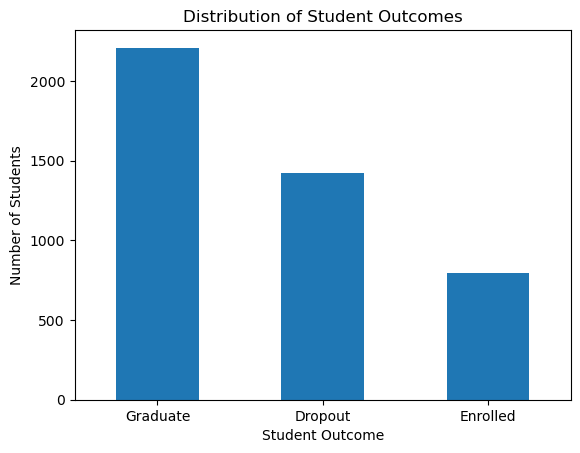

In [33]:
# Count the number of records in each outcome class
target_counts = df["Target"].value_counts()

display(target_counts)

# Plot the class distribution
target_counts.plot(kind="bar")

plt.title("Distribution of Student Outcomes")
plt.xlabel("Student Outcome")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

### 2.3.1.2 Understanding distribution of features

### Semester 1 Grade Distribution Interpretation

The histogram shows the distribution of students' average Semester 1 grades.

Most students are concentrated within the middle grade range, while a smaller number of students have very low or zero grades. These low values may indicate poor academic performance, incomplete assessments or early disengagement from studies.

Semester 1 grade is likely to be an important predictor of student outcome because it directly represents early academic performance. Students with stronger Semester 1 grades may be more likely to graduate, while students with lower grades may face a greater risk of remaining enrolled or dropping out.

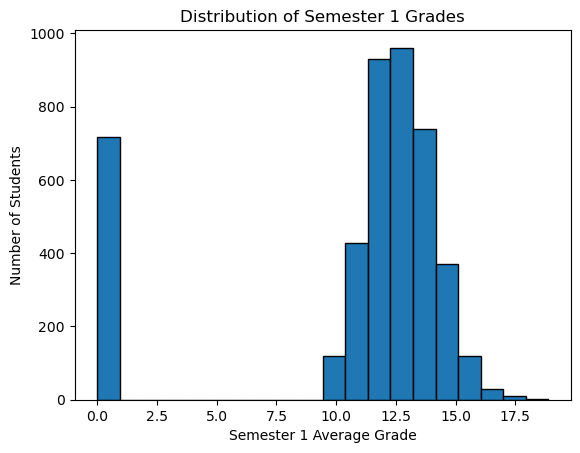

In [34]:
# Plot the distribution of Semester 1 grades
df["Curricular units 1st sem (grade)"].plot(
    kind="hist",
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Semester 1 Grades")
plt.xlabel("Semester 1 Average Grade")
plt.ylabel("Number of Students")

plt.show()

### 2.3.2 Understanding relationship between variables

### Approved Units and Student Outcome

The average number of approved Semester 1 curricular units differs clearly across the three student outcomes.

Graduate students have the highest average number of approved units, followed by students who remain Enrolled. Dropout students have the lowest average number of approved units.

This relationship suggests that early academic progress is strongly associated with a student's final outcome. The number of approved Semester 1 units may therefore be an important predictor for distinguishing between Graduate, Enrolled and Dropout students.

Target
Dropout     2.551724
Enrolled    4.318640
Graduate    6.232232
Name: Curricular units 1st sem (approved), dtype: float64

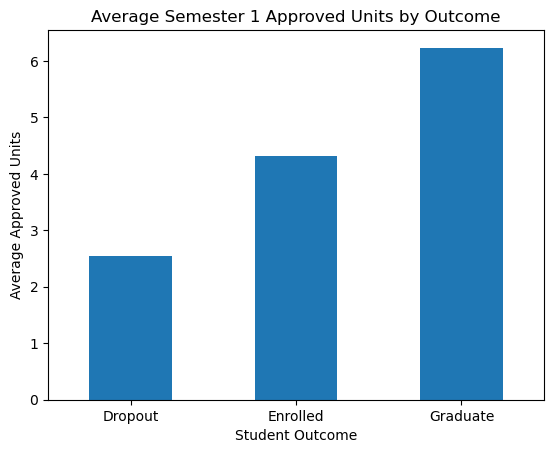

In [35]:
# Calculate the average number of approved Semester 1 units
# for each student outcome
approved_by_outcome = (
    df.groupby("Target")[
        "Curricular units 1st sem (approved)"
    ]
    .mean()
)

display(approved_by_outcome)

# Plot the average approved units by outcome
approved_by_outcome.plot(kind="bar")

plt.title("Average Semester 1 Approved Units by Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Average Approved Units")
plt.xticks(rotation=0)

plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

### Data Cleaning and Feature Engineering

A copy of the original dataset was created before making any changes so that the raw data remained unchanged.

Duplicate rows were checked and removed where necessary. Semester 2 variables were also removed because the prediction is intended to be made at the end of Semester 1. Including Semester 2 information would introduce data leakage because those values would not be available at the intended prediction time.

Two new features were created from the Semester 1 academic variables:

- **Semester 1 Pass Rate** measures the proportion of enrolled curricular units that were approved.
- **Semester 1 Completion Gap** measures the difference between enrolled and approved curricular units.

These engineered features provide clearer measures of a student's early academic performance and may help the classification models distinguish between Dropout, Enrolled and Graduate outcomes.

In [36]:
## Clean data
# Create a separate copy for modelling
model_df = df.copy()

# Remove duplicate rows
model_df = model_df.drop_duplicates().reset_index(drop=True)

print("Original number of rows:", len(df))
print("Rows after removing duplicates:", len(model_df))

# Find all Semester 2 columns
semester_2_columns = [
    column
    for column in model_df.columns
    if "2nd sem" in column.lower()
]

print("\nSemester 2 columns removed:")

for column in semester_2_columns:
    print("-", column)

# Remove Semester 2 columns
model_df = model_df.drop(columns=semester_2_columns)

# Create simple Semester 1 performance features
enrolled_units = model_df[
    "Curricular units 1st sem (enrolled)"
]

approved_units = model_df[
    "Curricular units 1st sem (approved)"
]

model_df["Sem1 Pass Rate"] = np.where(
    enrolled_units > 0,
    approved_units / enrolled_units,
    0
)

model_df["Sem1 Completion Gap"] = (
    enrolled_units - approved_units
)

display(
    model_df[
        ["Sem1 Pass Rate", "Sem1 Completion Gap"]
    ].head()
)

print("\nNew dataset shape:", model_df.shape)

Original number of rows: 4424
Rows after removing duplicates: 4424

Semester 2 columns removed:
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluations)


,Sem1 Pass Rate,Sem1 Completion Gap
0,0.000000,0
1,1.000000,0
2,0.000000,6
3,1.000000,0
4,0.833333,1



New dataset shape: (4424, 33)


## 3.2 Train-Test Split

### Train-Test Split Explanation

The input features were stored in `X`, while the student outcome was
stored in `y`.

The dataset was divided into 80% training data and 20% testing data.
The training set will be used to develop the models, while the test set
will be used to evaluate performance on unseen student records.

Stratification was used to preserve the proportions of Dropout, Enrolled
and Graduate students in both sets. A fixed random state was used to make
the split reproducible.

In [37]:
## Split data into train set and test set
# Separate the predictors from the target
X = model_df.drop(columns="Target")
y = model_df["Target"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the split
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training rows: 3539
Testing rows: 885

Training target distribution:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Testing target distribution:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64


### Data Preprocessing

The predictor variables were separated into categorical and numerical features.

Several variables are stored as numbers but represent categories, including course, application mode, marital status and previous qualification. These variables will be transformed using one-hot encoding so that the models do not incorrectly interpret the category codes as continuous measurements.

Numerical variables will be standardised using `StandardScaler`. Standardisation places numerical features on comparable scales and is particularly important for models such as Logistic Regression.

The preprocessing steps were combined using a `ColumnTransformer`. This transformer will be included inside each machine-learning pipeline and fitted only on the training data, helping to prevent data leakage.

In [38]:
# Variables that contain categories represented by numerical codes
categorical_candidates = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nationality",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

# Keep only columns that exist in this dataset
categorical_features = [
    column for column in categorical_candidates
    if column in X_train.columns
]

# All remaining columns are treated as numerical
numeric_features = [
    column for column in X_train.columns
    if column not in categorical_features
]

print("Number of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numeric_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Number of categorical features: 17
Number of numerical features: 15

Categorical features:
['Marital status', 'Application mode', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nationality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

Numerical features:
['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Sem1 Pass Rate', 'Sem1 Completion Gap']


In [39]:
# Preprocessing for numerical variables
numeric_transformer = StandardScaler()

# Preprocessing for categorical variables
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine both preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


# 4. Modelling

### 4.2 Train Model

### Baseline Model and Model Comparison

Three classification models were evaluated:

- **Dummy Classifier** was used as a baseline and predicted the most frequent outcome.
- **Logistic Regression** provided a relatively simple and interpretable classification model.
- **Random Forest** provided a more flexible ensemble model capable of learning non-linear relationships.

The models were evaluated using five-fold stratified cross-validation on the training set. Stratification preserved the proportions of Graduate, Dropout and Enrolled students within each fold.

Macro F1-score was used as the primary comparison metric because the target classes are imbalanced and this metric gives equal importance to all three outcomes. Accuracy and Dropout recall were also recorded.

The test set was not used during this comparison. It remains reserved for the final evaluation of the selected model.

In [40]:
# Create the baseline model
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

# Create the Logistic Regression model
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Create the Random Forest model
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

models = {
    "Dummy Classifier": dummy_pipeline,
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline
}

print("Models created successfully.")

Models created successfully.


In [41]:
# Calculate recall specifically for the Dropout class
def dropout_recall(y_true, y_pred):
    return recall_score(
        y_true,
        y_pred,
        labels=["Dropout"],
        average="macro",
        zero_division=0
    )


dropout_recall_scorer = make_scorer(dropout_recall)

# Five-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "dropout_recall": dropout_recall_scorer
}

In [42]:
# Initialise and train model
model_results = []

for model_name, model_pipeline in models.items():

    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    model_results.append({
        "Model": model_name,
        "Mean Accuracy": scores["test_accuracy"].mean(),
        "Mean Macro F1": scores["test_macro_f1"].mean(),
        "Mean Dropout Recall": scores["test_dropout_recall"].mean()
    })

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Mean Macro F1",
    ascending=False
).reset_index(drop=True)

display(results_df.round(3))

,Model,Mean Accuracy,Mean Macro F1,Mean Dropout Recall
0,Logistic Regression,0.721,0.678,0.710
1,Random Forest,0.752,0.658,0.765
2,Dummy Classifier,0.499,0.222,0.000


### Model Comparison Interpretation

Logistic Regression achieved the highest mean Macro F1-score of **0.678**, with a mean accuracy of **0.721** and a mean Dropout recall of **0.710**.

Random Forest achieved the highest mean accuracy of **0.752** and the highest Dropout recall of **0.765**. However, its Macro F1-score of **0.658** was lower than that of Logistic Regression, indicating that its performance was less balanced across the three outcome classes.

Both machine-learning models performed substantially better than the Dummy Classifier, which achieved a Macro F1-score of only **0.222**. This demonstrates that the models learned meaningful relationships from the student data rather than simply predicting the majority class.

Since Macro F1-score was selected as the primary evaluation metric, Logistic Regression was selected for hyperparameter tuning. Random Forest remains a useful comparison because of its stronger accuracy and Dropout recall.

## 4.3 Hyperparameter Tuning

In [43]:
# Define compatible Logistic Regression hyperparameters
logistic_param_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__solver": ["lbfgs", "newton-cg", "saga"],
    "model__class_weight": [None, "balanced"]
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


In [44]:
# Tune Logistic Regression using only the training data
random_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_param_grid,
    n_iter=12,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise"
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.1, 1.0, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['lbfgs', 'newton-cg', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionch

In [45]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(round(random_search.best_score_, 3))

Best parameters:
{'model__solver': 'saga', 'model__class_weight': 'balanced', 'model__C': 0.1}

Best cross-validation Macro F1:
0.685


### Hyperparameter Tuning Interpretation

The best Logistic Regression configuration used a regularisation strength of **C = 0.1**, the **saga** solver and **balanced** class weights.

The tuned model achieved a cross-validation Macro F1-score of **0.685**, compared with **0.678** for the original Logistic Regression model. This represents an improvement of **0.007**.

Although the improvement was relatively small, the tuned model provided the best balanced cross-validation performance across the three student outcome classes. The complete tuned pipeline was saved as `best_model` for final evaluation using the untouched test set.

In [46]:
# Convert the tuning results into a readable comparison table
tuning_results = pd.DataFrame(
    random_search.cv_results_
)

tuning_summary = tuning_results[
    [
        "param_model__C",
        "param_model__solver",
        "param_model__class_weight",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

tuning_summary = tuning_summary.rename(
    columns={
        "param_model__C": "C",
        "param_model__solver": "Solver",
        "param_model__class_weight": "Class Weight",
        "mean_train_score": "Mean Train Macro F1",
        "mean_test_score": "Mean Validation Macro F1",
        "std_test_score": "Validation F1 Standard Deviation",
        "rank_test_score": "Rank"
    }
)

tuning_summary = tuning_summary.sort_values(
    by="Rank"
).reset_index(drop=True)

display(tuning_summary.head(10).round(3))

,C,Solver,Class Weight,Mean Train Macro F1,Mean Validation Macro F1,Validation F1 Standard Deviation,Rank
0,0.1,saga,balanced,0.720,0.685,0.019,1
1,0.1,lbfgs,balanced,0.720,0.685,0.020,2
2,1.0,lbfgs,balanced,0.733,0.678,0.020,3
3,1.0,saga,balanced,0.733,0.678,0.019,4
4,10.0,lbfgs,balanced,0.737,0.669,0.023,5
5,10.0,saga,balanced,0.737,0.669,0.023,6
6,10.0,newton-cg,balanced,0.737,0.669,0.023,7
7,1.0,saga,None,0.720,0.662,0.015,8
8,10.0,newton-cg,None,0.731,0.662,0.014,9
9,0.1,lbfgs,None,0.686,0.650,0.014,10


In [47]:
# Retrieve the original Logistic Regression result
initial_logistic_f1 = results_df.loc[
    results_df["Model"] == "Logistic Regression",
    "Mean Macro F1"
].iloc[0]

tuned_logistic_f1 = random_search.best_score_
f1_improvement = tuned_logistic_f1 - initial_logistic_f1

print(
    "Original Logistic Regression Macro F1:",
    round(initial_logistic_f1, 3)
)

print(
    "Tuned Logistic Regression Macro F1:",
    round(tuned_logistic_f1, 3)
)

print(
    "Macro F1 improvement:",
    round(f1_improvement, 3)
)

Original Logistic Regression Macro F1: 0.678
Tuned Logistic Regression Macro F1: 0.685
Macro F1 improvement: 0.007


In [48]:
# Save the complete tuned pipeline
best_model = random_search.best_estimator_

print("Best tuned model saved as best_model.")

Best tuned model saved as best_model.


### Hyperparameter Tuning

Logistic Regression was selected for hyperparameter tuning because it achieved the highest mean Macro F1-score during the initial model comparison.

`RandomizedSearchCV` was used to test different values for the regularisation strength, optimisation solver and class-weight setting. The search used five-fold stratified cross-validation and Macro F1-score as the optimisation metric.

The preprocessing transformer remained inside the model pipeline. Therefore, preprocessing was fitted separately within each cross-validation fold, reducing the risk of data leakage.

The test set was not used during hyperparameter tuning and remained reserved for the final evaluation.

# 5. Model Evaluation

In [49]:
## Evaluate model
# Generate predictions using the untouched test set
y_test_pred = best_model.predict(X_test)

print("Test-set predictions created successfully.")

Test-set predictions created successfully.


In [50]:
# Calculate final evaluation metrics
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_dropout_recall = recall_score(
    y_test,
    y_test_pred,
    labels=["Dropout"],
    average="macro",
    zero_division=0
)

print("Final Test Accuracy:", round(test_accuracy, 3))
print("Final Test Macro F1:", round(test_macro_f1, 3))
print("Final Test Dropout Recall:", round(test_dropout_recall, 3))

Final Test Accuracy: 0.715
Final Test Macro F1: 0.678
Final Test Dropout Recall: 0.673


In [51]:
# Display precision, recall and F1-score for each outcome
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=["Dropout", "Enrolled", "Graduate"],
        digits=3,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Dropout      0.806     0.673     0.733       284
    Enrolled      0.407     0.616     0.490       159
    Graduate      0.845     0.778     0.810       442

    accuracy                          0.715       885
   macro avg      0.686     0.689     0.678       885
weighted avg      0.754     0.715     0.728       885



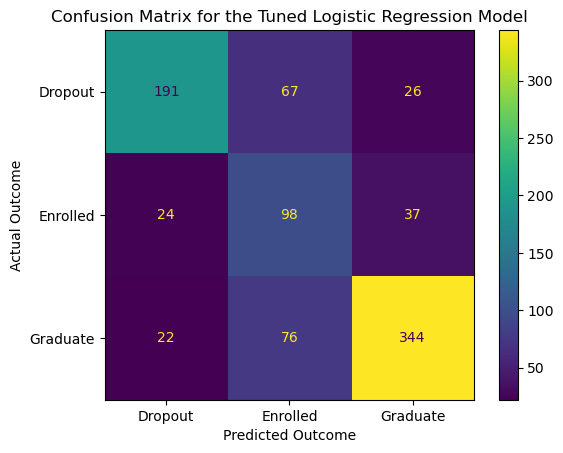

In [52]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=["Dropout", "Enrolled", "Graduate"]
)

plt.title("Confusion Matrix for the Tuned Logistic Regression Model")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")

plt.show()

In [53]:
# Select one unseen student record as a prediction example
example_student = X_test.iloc[[0]].copy()

# Generate the predicted outcome
example_prediction = best_model.predict(
    example_student
)[0]

# Generate probabilities for each outcome
example_probabilities = best_model.predict_proba(
    example_student
)[0]

probability_table = pd.DataFrame({
    "Outcome": best_model.classes_,
    "Predicted Probability": example_probabilities
}).sort_values(
    by="Predicted Probability",
    ascending=False
).reset_index(drop=True)

print("Predicted outcome:", example_prediction)
print("Actual outcome:", y_test.iloc[0])

display(probability_table.round(3))

Predicted outcome: Graduate
Actual outcome: Graduate


,Outcome,Predicted Probability
0,Graduate,0.600
1,Enrolled,0.339
2,Dropout,0.060


### Final Model Evaluation

The tuned Logistic Regression pipeline was evaluated using the untouched test set. This test set was not used during model training, model comparison or hyperparameter tuning.

The final model was evaluated using accuracy, Macro F1-score and Dropout recall. Macro F1-score remained the primary metric because it gives equal importance to the Dropout, Enrolled and Graduate classes.

A classification report was used to examine precision, recall and F1-score for each student outcome. A confusion matrix was also produced to show the number of correct predictions and the types of errors made by the model.

### Final Evaluation Interpretation

The tuned Logistic Regression model achieved a test accuracy of **0.715**, a Macro F1-score of **0.678**, and a Dropout recall of **0.673**.

The model performed best when predicting the Graduate class, which achieved an F1-score of **0.810**. The Dropout class achieved an F1-score of **0.733**, while the Enrolled class was the most difficult to predict, with an F1-score of **0.490**.

The model correctly predicted 191 Dropout students, 98 Enrolled students and 344 Graduate students. The most common errors involved predicting actual Dropout or Graduate students as Enrolled. In particular, 67 Dropout students and 76 Graduate students were incorrectly predicted as Enrolled.

Overall, the tuned model performed substantially better than the Dummy Classifier baseline. The results demonstrate that Semester 1 academic, demographic and financial variables provide useful early indications of student outcomes. However, the lower performance for the Enrolled class indicates that this outcome is more difficult to distinguish from Dropout and Graduate.

## Iterative model development


Feature engineering was performed before model development by creating Semester 1 Pass Rate and Semester 1 Completion Gap. Multiple classification algorithms were then compared, and the strongest model according to Macro F1-score was optimised using hyperparameter tuning.

No further model changes were made after examining the final test-set results. This prevents the test data from influencing model development and preserves the test set as an unbiased measure of final performance.

Future iterations could investigate additional feature selection, alternative class-balancing methods or other classification algorithms. Particular attention could be given to improving performance for the Enrolled class, which was the most difficult outcome to predict.

In [57]:
# Create default values for the Streamlit application
feature_defaults = {}

for column in X_train.columns:

    if column in categorical_features:
        # Use the most common category
        default_value = X_train[column].mode().iloc[0]
    else:
        # Use the median for numerical variables
        default_value = X_train[column].median()

    # Convert NumPy values to standard Python values
    if hasattr(default_value, "item"):
        default_value = default_value.item()

    feature_defaults[column] = default_value


# Store the model and supporting information together
model_bundle = {
    "model": best_model,
    "feature_columns": X_train.columns.tolist(),
    "feature_defaults": feature_defaults,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "metrics": {
        "test_accuracy": float(test_accuracy),
        "test_macro_f1": float(test_macro_f1),
        "test_dropout_recall": float(test_dropout_recall)
    }
}


# Save the bundle in the project folder
model_path = Path("student_outcome_model.joblib")

joblib.dump(
    model_bundle,
    model_path
)

print("Model bundle saved successfully.")
print("Saved location:", model_path.resolve())

Model bundle saved successfully.
Saved location: C:\Users\andre\Downloads\Student Outcome\student_outcome_model.joblib


In [58]:
# Load the saved bundle to verify it
loaded_bundle = joblib.load(
    "student_outcome_model.joblib"
)

loaded_model = loaded_bundle["model"]

# Test the loaded model using one unseen record
verification_prediction = loaded_model.predict(
    X_test.iloc[[0]]
)[0]

original_prediction = best_model.predict(
    X_test.iloc[[0]]
)[0]

print("Original model prediction:", original_prediction)
print("Loaded model prediction:", verification_prediction)

assert verification_prediction == original_prediction

print("Model verification successful.")

Original model prediction: Graduate
Loaded model prediction: Graduate
Model verification successful.


### Model Persistence

The complete tuned machine-learning pipeline was saved using Joblib. The saved object contains both the preprocessing transformer and the Logistic Regression model, allowing future predictions to use exactly the same preprocessing steps applied during training.

Default feature values and the final evaluation metrics were also stored in the model bundle to support development of the Streamlit application.

The saved model was loaded again and tested using an unseen record. Its prediction matched the original pipeline's prediction, confirming that the model was saved successfully.